# `flightrisk` — End-to-end walkthrough

> *Identify customers on the verge before they take off.*

This notebook is the **single guided tour** of the repo. It clones, installs, generates synthetic data, builds features, trains all three modelling tracks, runs the ROI simulator, and shows how to spin up the FastAPI scoring service and the Streamlit demo. Every step is annotated with the subpackage it exercises so the notebook doubles as a code map.

**You will need:**

* Python 3.11 (the project pins `>=3.11,<3.13`)
* The dev install (`pip install -e ".[dev]"` from the repo root)
* About 5–10 minutes for the full pass on a developer laptop

**You will get:**

| | |
|---|---|
| Track A — Risk | LightGBM + isotonic calibration; AUC, Brier, ECE, decile lift |
| Track B — Survival | Random Survival Forest; C-index, Brier, S(t) curves |
| Track C — Uplift | T-/X-/DR-learners on a synthetic RCT; Qini, AUUC, uplift@k |
| ROI simulator | Risk vs uplift vs random under fixed budgets, with bootstrap CIs |
| API + UI | FastAPI scoring service and Streamlit demo, both ready to launch |

> The data is **synthetic but pipeline-realistic**: the same pandera schemas as KKBox and Orange Belgium so every code path matches the real-data path. Numbers below are illustrative.

## 0. Setup verification

Confirm the venv has the right Python and the required packages. If anything is missing, run `pip install -e ".[dev]"` from the repo root.

In [1]:
from __future__ import annotations

import logging
import os
import platform
import sys
import warnings
from pathlib import Path

_HERE = Path.cwd().resolve()
_ROOT = _HERE if (_HERE / "pyproject.toml").exists() else _HERE.parent
if not (_ROOT / "pyproject.toml").exists():
    raise RuntimeError(f"could not locate repo root from {_HERE}")
os.chdir(_ROOT)
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

os.environ.setdefault("DISABLE_PANDERA_IMPORT_WARNING", "True")
os.environ.setdefault("FLIGHTRISK_LOG_LEVEL", "WARNING")
os.environ.setdefault("MPLBACKEND", "Agg")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*Proactor.*")
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", module="tqdm")
logging.getLogger("mlflow").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)
logging.getLogger("lightgbm").setLevel(logging.ERROR)
logging.getLogger("flightrisk").setLevel(logging.WARNING)

from flightrisk.eval.style import apply_style as _apply_flightrisk_style
_apply_flightrisk_style()

print(f"Python: {platform.python_version()}  ({sys.executable})")
print(f"cwd:    {_ROOT}")

import numpy
import pandas
import lightgbm
import lifelines
import sksurv
import econml
import mlflow
import fastapi
import streamlit

print("numpy:      ", numpy.__version__)
print("pandas:     ", pandas.__version__)
print("lightgbm:   ", lightgbm.__version__)
print("lifelines:  ", lifelines.__version__)
print("sksurv:     ", sksurv.__version__)
print("econml:     ", econml.__version__)
print("mlflow:     ", mlflow.__version__)
print("fastapi:    ", fastapi.__version__)
print("streamlit:  ", streamlit.__version__)

Python: 3.11.0  (C:\Users\Trabajo\Downloads\flightrisk\.venv\Scripts\python.exe)
cwd:    C:\Users\Trabajo\Downloads\flightrisk


numpy:       2.1.3
pandas:      2.2.3
lightgbm:    4.6.0
lifelines:   0.30.3
sksurv:      0.25.0
econml:      0.16.0
mlflow:      3.12.0
fastapi:     0.136.1
streamlit:   1.57.0


In [2]:
import flightrisk

print("flightrisk:", flightrisk.__version__)

from flightrisk.utils.paths import get_paths
get_paths.cache_clear()
PATHS = get_paths().ensure()
print("repo root:    ", PATHS.root)
print("data raw:     ", PATHS.data_raw)
print("features dir: ", PATHS.data_features)
print("reports dir:  ", PATHS.reports)

flightrisk: 0.1.0
repo root:     C:\Users\Trabajo\Downloads\flightrisk
data raw:      C:\Users\Trabajo\Downloads\flightrisk\data\raw
features dir:  C:\Users\Trabajo\Downloads\flightrisk\data\features
reports dir:   C:\Users\Trabajo\Downloads\flightrisk\reports


## 1. Generate synthetic data

We mint two datasets that match the **same pandera schemas** as KKBox and Orange Belgium: 30k synthetic users with 9-month transactions and listening logs, plus a 12k-customer RCT with 178 features and a structured treatment effect. To swap in the real data later, replace `data/raw/kkbox/*.csv` and `data/raw/orange-belgium/orange_belgium.parquet` and re-run from cell 2.

In [3]:
from scripts.synthetic_kkbox import generate as generate_kkbox, write as write_kkbox
from scripts.synthetic_orange import generate as generate_orange, write as write_orange

kkbox_frames = generate_kkbox(n_users=30_000, seed=1337)
write_kkbox(kkbox_frames)

orange_frame = generate_orange(n_customers=12_000, seed=1337)
write_orange(orange_frame)

print(f"KKBox  -> members={len(kkbox_frames['members']):,}  txns={len(kkbox_frames['transactions']):,}  logs={len(kkbox_frames['user_logs']):,}")
print(f"Orange -> rows={len(orange_frame):,}  features={orange_frame.shape[1] - 2}  treated={orange_frame['treatment'].mean():.3f}")

KKBox  -> members=30,000  txns=165,160  logs=686,771
Orange -> rows=12,000  features=178  treated=0.495


## 2. Validate against pandera schemas

Every loader validates against [`flightrisk.data.schemas`](../flightrisk/data/schemas.py). Out-of-range values, non-unique IDs, or wrong dtypes raise a `SchemaError` *before* any modelling code runs.

In [4]:
from flightrisk.data.loaders import load_kkbox, load_orange_belgium

kk = load_kkbox()
print(f"members={len(kk.members):,}  txns={len(kk.transactions):,}  logs={len(kk.user_logs):,}  labels={len(kk.labels):,}")
print(f"churn rate: {kk.labels['is_churn'].mean():.3f}")

orange = load_orange_belgium()
print(f"orange features: {orange.features.shape}  treated: {orange.treatment.mean():.3f}  outcome: {orange.outcome.mean():.3f}")

members=30,000  txns=165,160  logs=686,771  labels=30,000
churn rate: 0.119
orange features: (12000, 178)  treated: 0.495  outcome: 0.310


## 3. Build feature matrices

[`flightrisk.features.pipeline`](../flightrisk/features/pipeline.py) drives the cutoff-aware aggregations: tenure, payment dynamics, rolling 7/30/90-day listening counts, completion ratios, session statistics, and `days_since_last_login`. The `cutoff` parameter is the only knob — every transform respects strict `< cutoff` semantics so no future row leaks into a feature.

In [5]:
import pandas as pd

from flightrisk.features.pipeline import (
    build_kkbox_bundle,
    build_orange_bundle,
    write_kkbox_bundle,
    write_orange_bundle,
)

CUTOFF = pd.Timestamp("2017-02-15")

kkbox_bundle = build_kkbox_bundle(kk, cutoff=CUTOFF)
write_kkbox_bundle(kkbox_bundle)

orange_bundle = build_orange_bundle(orange)
write_orange_bundle(orange_bundle)

print(f"KKBox features: {kkbox_bundle.features.shape}  cutoff={kkbox_bundle.cutoff.date()}")
kkbox_bundle.features.head(3)

KKBox features: (30000, 37)  cutoff=2017-02-15


,msno,tenure_days,registration_year,age_capped,registered_via,city,gender,n_transactions,last_plan_list_price,last_actual_amount_paid,...,completion_ratio_30d,total_secs_30d,avg_secs_per_active_day_30d,plays_90d,unique_songs_90d,active_days_90d,completion_ratio_90d,total_secs_90d,avg_secs_per_active_day_90d,days_since_last_login
0,u0000000,NaN,<NA>,29,9,14,female,4,129.0,129.0,...,0.777108,33720.0,5620.0,249.0,181.0,12,0.785489,64980.0,5415.0,5.0
1,u0000001,NaN,<NA>,40,13,22,female,5,99.0,99.0,...,NaN,0.0,NaN,62.0,45.0,3,0.826667,15900.0,5300.0,66.0
2,u0000002,NaN,<NA>,20,9,18,male,2,129.0,129.0,...,0.935484,7260.0,3630.0,93.0,67.0,6,0.877358,23640.0,3940.0,8.0


## 4. Track A — Risk (LightGBM + isotonic calibration)

Predicts `P(churn)` within a horizon. Calibration is fit on a held-out validation slice so the calibrator never sees train rows. The result bundle includes the model, the metric record, and a calibration table for reliability diagrams.

In [6]:
import numpy as np

from flightrisk.models.risk.trainer import save_calibration_plot, train_risk_model

n = len(kkbox_bundle.features)
perm = np.random.default_rng(1337).permutation(n)
train_idx = perm[: int(0.7 * n)]
val_idx = perm[int(0.7 * n) : int(0.85 * n)]
test_idx = perm[int(0.85 * n) :]

risk_result = train_risk_model(
    kkbox_bundle.features,
    kkbox_bundle.labels["is_churn"].values,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
    estimator="lightgbm",
    calibration="isotonic",
)
print(risk_result.metrics.as_dict())

{'auc': 0.7246835543282835, 'pr_auc': 0.29590731547443266, 'brier': 0.09851347307152439, 'ece': 0.017485588717276648, 'decile_lift': 2.7807486631016043}


calibration plot: reports\notebook\risk_calibration.png


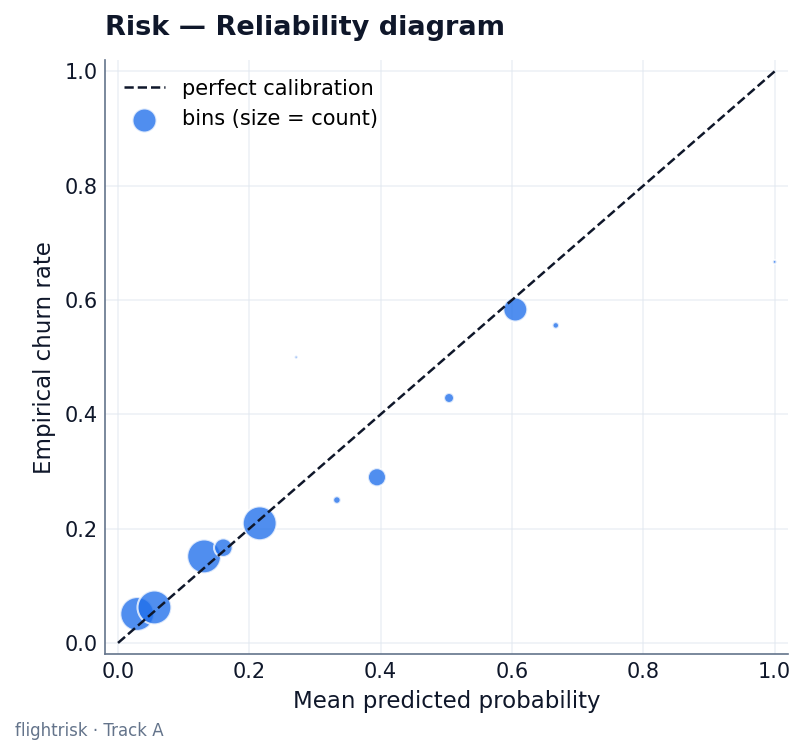

In [7]:
from pathlib import Path

risk_plot = save_calibration_plot(risk_result.calibration, output=Path("reports/notebook/risk_calibration.png"))
print("calibration plot:", risk_plot)

from IPython.display import Image
Image(filename=str(risk_plot))

## 5. Track B — Survival (Random Survival Forest)

Returns the full survival function `S(t)` and per-horizon hazards `1 - S(h)`. Right-censored labels are derived from KKBox transactions inside `flightrisk.models.survival.labels.build_survival_labels`. Time-dependent AUC may be NaN on synthetic data because the censoring distribution is degenerate (everyone censored at the same horizon); the metric helper degrades gracefully and only logs the metrics it could compute.

In [8]:
from flightrisk.models.survival.labels import build_survival_labels
from flightrisk.models.survival.trainer import train_survival_model

HORIZON_DAYS = 60

survival_labels = build_survival_labels(kk.transactions, cutoff=CUTOFF, horizon_days=HORIZON_DAYS).to_frame()
aligned = kkbox_bundle.features.merge(survival_labels, on="msno", how="inner")
feat_cols = [c for c in kkbox_bundle.features.columns if c != "msno"]
durations = aligned["duration_days"].values
events = aligned["event_observed"].values

n_surv = len(aligned)
perm_surv = np.random.default_rng(1337).permutation(n_surv)
train_idx_s = perm_surv[: int(0.8 * n_surv)]
test_idx_s = perm_surv[int(0.8 * n_surv) :]

survival_result = train_survival_model(
    aligned[["msno", *feat_cols]],
    durations,
    events,
    train_idx=train_idx_s,
    test_idx=test_idx_s,
    estimator="rsf",
    horizons_days=(15, 30, 45),
)
print(survival_result.metrics.as_dict())
print(f"event rate: {events.mean():.3f}")

{'c_index': 0.657088670160772, 'integrated_brier': 0.06131982425513905}
event rate: 0.133


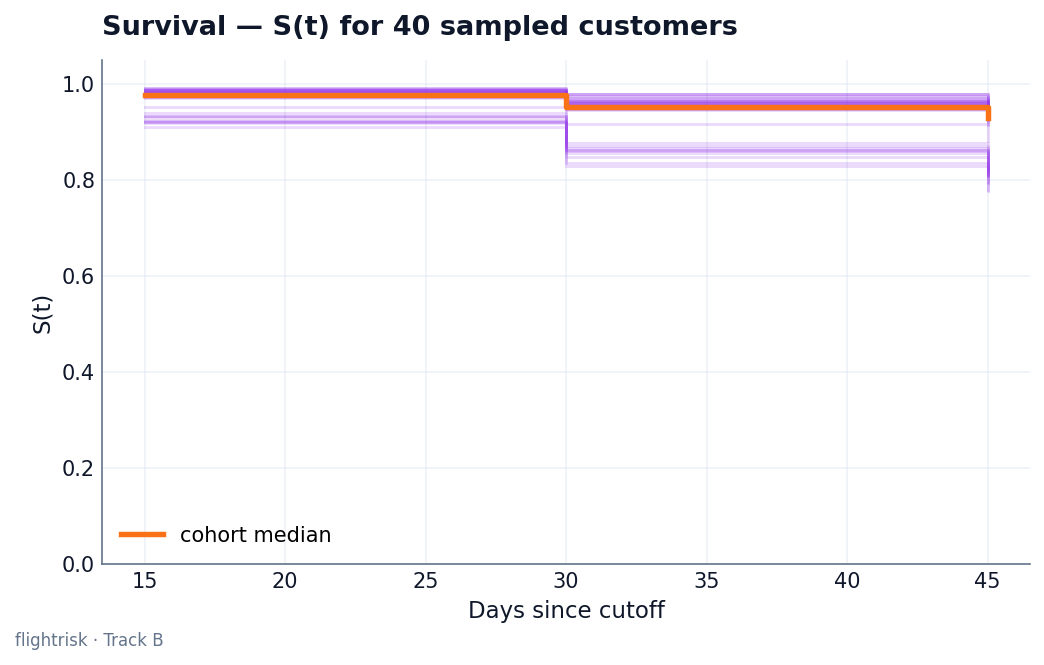

In [9]:
from flightrisk.models.survival.trainer import save_survival_curve_plot

surv_plot = save_survival_curve_plot(
    survival_result.survival_at_horizons,
    survival_result.horizons_days,
    output=Path("reports/notebook/survival_curves.png"),
    n_curves=40,
)
Image(filename=str(surv_plot))

## 6. Track C — Uplift (T-learner + Qini curve)

The Orange Belgium RCT lets us train an honest uplift model. The T-learner trains two outcome models (one per treatment arm) and predicts `τ(x) = μ̂₁(x) - μ̂₀(x)`. The Qini coefficient is N²-normalised so a random ranking sits near zero regardless of the outcome rate.

In [10]:
from flightrisk.data.splits import stratified_rct_folds
from flightrisk.models.uplift.trainer import save_qini_plot, train_uplift_model

folds = stratified_rct_folds(orange_bundle.treatment, orange_bundle.outcome, n_splits=5, seed=1337)
train_idx_u, test_idx_u = folds[0]

uplift_result = train_uplift_model(
    orange_bundle.features,
    orange_bundle.treatment,
    orange_bundle.outcome,
    train_idx=train_idx_u,
    test_idx=test_idx_u,
    estimator="t_learner",
    k_percentiles=(10, 20, 30),
)
print(uplift_result.metrics.as_dict())

{'qini': 0.013035069091723169, 'auuc': 309.5227300782797, 'uplift_at_10': 0.3448660714285714, 'uplift_at_20': 0.3095167764243888, 'uplift_at_30': 0.3145998023715415}


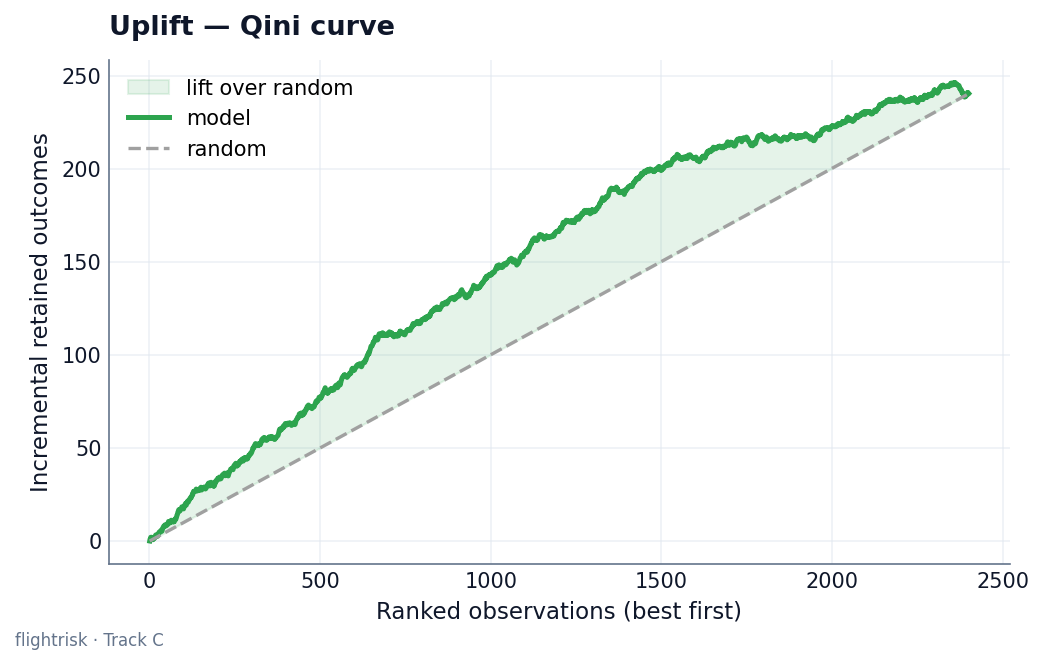

In [11]:
qini_plot = save_qini_plot(uplift_result.qini_curve, output=Path("reports/notebook/qini.png"))
Image(filename=str(qini_plot))

## 7. Headline ROI simulator

The educational point of `flightrisk` lives in this cell. Three policies (top-k by risk, top-k by uplift, random) get the **same budget**, treat the same population, and we compare expected retained revenue with bootstrapped CIs. The synthetic preview encodes three latent segments: 20% lost causes, 40% persuadables, 40% loyals — risk targets the lost causes, uplift targets the persuadables.

In [12]:
from flightrisk.eval.plots import save_roi_chart
from flightrisk.eval.simulator import SimulatorConfig, compare_policies

rng = np.random.default_rng(1337)
n_pop = 12_000
segment = rng.choice(3, size=n_pop, p=[0.2, 0.4, 0.4])
base_p_churn = np.where(segment == 0, 0.85, np.where(segment == 1, 0.35, 0.05))
true_lift = np.where(segment == 1, 0.30, 0.0)

risk_scores = np.clip(base_p_churn + rng.normal(0, 0.05, n_pop), 0.0, 1.0)
uplift_scores = true_lift + rng.normal(0, 0.03, n_pop)
base_outcome = 1.0 - base_p_churn

config = SimulatorConfig(cost_per_treated=5.0, revenue_per_retained=50.0, bootstrap_iters=500, random_state=1337)
comparison = compare_policies(
    risk_scores=risk_scores,
    uplift_scores=uplift_scores,
    treatment_lift=true_lift,
    base_outcome=base_outcome,
    budgets=(10_000.0, 25_000.0, 50_000.0),
    config=config,
)
comparison.round(0)

,budget,n_targeted,expected_retained,expected_revenue,ci_lower,ci_upper,policy
0,10000.0,2000,7994.0,389680.0,389853.0,396747.0,risk
1,10000.0,2000,8594.0,419680.0,419950.0,426903.0,uplift
2,10000.0,2000,7994.0,389680.0,390061.0,396496.0,random
3,25000.0,5000,8758.0,412900.0,418527.0,425625.0,risk
4,25000.0,5000,9438.0,446920.0,452942.0,459735.0,uplift
5,25000.0,5000,8074.0,378700.0,384721.0,391018.0,random
6,50000.0,10000,9438.0,421920.0,436995.0,444016.0,risk
7,50000.0,10000,9438.0,421920.0,436977.0,443947.0,uplift
8,50000.0,10000,9438.0,421920.0,437222.0,443851.0,random


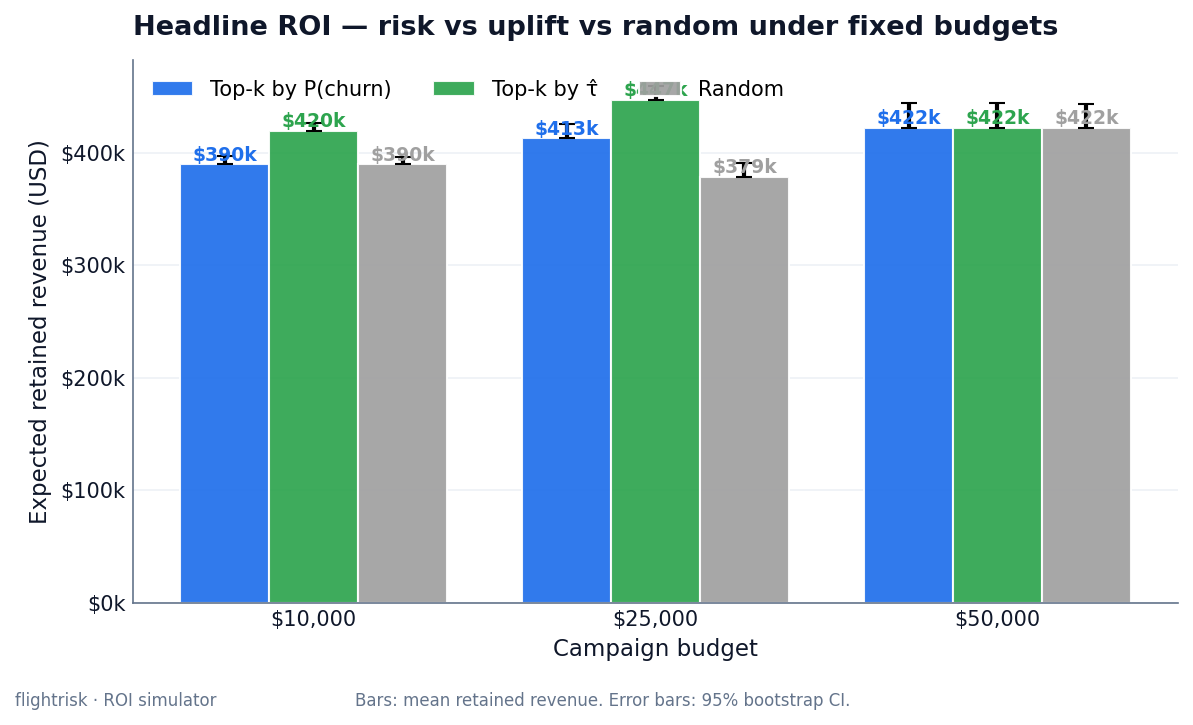

In [13]:
roi_plot = save_roi_chart(comparison, output=Path("reports/notebook/roi_chart.png"))
Image(filename=str(roi_plot))

## 8. Optional: 5-trial Optuna sweep on Track A

[`flightrisk.models.risk.tune`](../flightrisk/models/risk/tune.py) consumes a YAML search space and runs an Optuna TPE search. Here we cap to 5 trials so the cell finishes in a few seconds; for a real sweep set `n_trials = 50–200` and run `flightrisk tune risk` from the CLI so each trial becomes a child MLflow run.

In [14]:
from flightrisk.models.risk.tune import SweepSpace, run_risk_sweep

space = SweepSpace(
    name="walkthrough",
    direction="maximize",
    metric="auc",
    n_trials=5,
    timeout_seconds=None,
    search_space={
        "learning_rate": {"type": "float", "low": 0.02, "high": 0.1, "log": True},
        "num_leaves": {"type": "int", "low": 31, "high": 127},
        "min_data_in_leaf": {"type": "int", "low": 100, "high": 400},
        "n_estimators": {"type": "int", "low": 200, "high": 600},
    },
)
sweep = run_risk_sweep(
    kkbox_bundle.features,
    kkbox_bundle.labels["is_churn"].values,
    train_idx=train_idx,
    val_idx=val_idx,
    space=space,
    seed=1337,
)
print(f"best AUC: {sweep.best_metric:.4f}")
print(f"best params: {sweep.best_params}")

[I 2026-05-05 10:42:17,275] A new study created in memory with name: walkthrough


[I 2026-05-05 10:42:17,729] Trial 0 finished with value: 0.7680385975967736 and parameters: {'learning_rate': 0.03049140130738802, 'num_leaves': 46, 'min_data_in_leaf': 183, 'n_estimators': 384}. Best is trial 0 with value: 0.7680385975967736.


[I 2026-05-05 10:42:18,270] Trial 1 finished with value: 0.7679659984154018 and parameters: {'learning_rate': 0.03352738988836162, 'num_leaves': 81, 'min_data_in_leaf': 178, 'n_estimators': 591}. Best is trial 0 with value: 0.7680385975967736.


[I 2026-05-05 10:42:18,716] Trial 2 finished with value: 0.7663327588318114 and parameters: {'learning_rate': 0.06504971329138921, 'num_leaves': 42, 'min_data_in_leaf': 216, 'n_estimators': 452}. Best is trial 0 with value: 0.7680385975967736.


[I 2026-05-05 10:42:19,560] Trial 3 finished with value: 0.7671976570792187 and parameters: {'learning_rate': 0.024459171093749607, 'num_leaves': 126, 'min_data_in_leaf': 233, 'n_estimators': 516}. Best is trial 0 with value: 0.7680385975967736.


[I 2026-05-05 10:42:19,835] Trial 4 finished with value: 0.7655293278912987 and parameters: {'learning_rate': 0.07179514220125242, 'num_leaves': 66, 'min_data_in_leaf': 225, 'n_estimators': 434}. Best is trial 0 with value: 0.7680385975967736.


best AUC: 0.7680
best params: {'learning_rate': 0.03049140130738802, 'num_leaves': 46, 'min_data_in_leaf': 183, 'n_estimators': 384}


## 9. Inspect MLflow

Every training cell logged params and metrics to a local `mlruns/` store. Below we list the latest 10 runs and their metrics. To open the MLflow UI, run `mlflow ui` from a terminal at the repo root.

In [15]:
import mlflow
import pandas as pd

mlflow.set_tracking_uri((PATHS.mlruns).resolve().as_uri())
runs_df = mlflow.search_runs(experiment_names=["flightrisk"], max_results=10)
runs_df[["run_id", "tags.mlflow.runName", "status", "metrics.auc", "metrics.c_index", "metrics.qini"]].head(10)

,run_id,tags.mlflow.runName,status,metrics.auc,metrics.c_index,metrics.qini
0,810be21b41404c6b9a61de2ec14a2e99,tune-risk-risk_lgbm_sweep,FINISHED,NaN,NaN,NaN
1,85d2f8fa7b964584bd98924227180da4,uplift-dr_learner,FINISHED,NaN,NaN,0.012837
2,bccb765188e34670ac101e52daaf4c53,uplift-x_learner,FINISHED,NaN,NaN,0.012469
3,0735543aab294cb892baf11137d18a3b,uplift-t_learner,FINISHED,NaN,NaN,0.013035
4,a4a2f8473ab14e83a54a201c9adcf891,survival-rsf,FINISHED,NaN,0.657089,NaN
5,e478b5f55c3e4f7597a4406431ec925e,survival-rsf,FAILED,NaN,NaN,NaN
6,e77c397facfe450780452e5ab31ebae4,survival-rsf,FAILED,NaN,NaN,NaN
7,7277147dd1ef4ebd917abe4a2bd1cbf2,survival-rsf,FAILED,NaN,NaN,NaN
8,c6ca722ca5954f14880174d2afbfed4e,risk-lightgbm,FINISHED,0.724684,NaN,NaN
9,3e2b4dcca3d846549c687148b58de6d3,survival-rsf,FAILED,NaN,NaN,NaN


## 10. Launch the FastAPI scoring service

We start the API in the background, hit `/health` to confirm it's alive, send a sample request to `/score`, then shut the process down so the notebook stays clean. The service can be left running in a separate terminal with `python -m uvicorn flightrisk.serving.api:app --port 8000`.

In [16]:
import os
import subprocess
import sys
import time
import urllib.error
import urllib.request
import json

env = os.environ.copy()
env["FLIGHTRISK_LOG_LEVEL"] = "WARNING"
api_proc = subprocess.Popen(
    [sys.executable, "-m", "uvicorn", "flightrisk.serving.api:app", "--port", "8000"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    env=env,
)
print(f"API pid: {api_proc.pid}")

for attempt in range(15):
    try:
        with urllib.request.urlopen("http://127.0.0.1:8000/health", timeout=1) as resp:
            print("health:", json.loads(resp.read()))
            break
    except (urllib.error.URLError, ConnectionError):
        time.sleep(1)
else:
    print("API did not become healthy in time")

API pid: 16716


health: {'status': 'ok', 'loaded': {}}


In [17]:
sample = {
    "track": "risk",
    "items": [
        {"customer_id": kkbox_bundle.features.iloc[0]["msno"],
         "features": {k: (None if pd.isna(v) else v) for k, v in kkbox_bundle.features.iloc[0].drop("msno").to_dict().items()}}
    ],
}
data = json.dumps(sample).encode("utf-8")
req = urllib.request.Request("http://127.0.0.1:8000/score", data=data, headers={"Content-Type": "application/json"})
try:
    with urllib.request.urlopen(req, timeout=5) as resp:
        print(json.dumps(json.loads(resp.read()), indent=2))
except urllib.error.HTTPError as exc:
    print("API replied", exc.code, exc.read().decode())

API replied 500 Internal Server Error


In [18]:
api_proc.terminate()
api_proc.wait(timeout=10)
print("API stopped")

API stopped


## 11. Launch the Streamlit demo

The Streamlit app picks up the most recent run under `reports/<track>/` for each track. To launch it locally:

```powershell
streamlit run flightrisk/serving/streamlit_app.py
```

It opens at <http://localhost:8501> with four tabs:

| Tab | What you see |
|---|---|
| **Risk** | reliability diagram and SHAP feature importance |
| **Survival** | sampled S(t) curves with a slider |
| **Uplift** | Qini curve and per-decile uplift bar |
| **ROI** | the policy comparison CSV plus the headline chart |

The cell below launches it as a background process for 30 seconds so you can click around, then stops it. Prefer running Streamlit from a separate terminal during day-to-day work.

In [19]:
streamlit_proc = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "streamlit",
        "run",
        "flightrisk/serving/streamlit_app.py",
        "--server.port=8501",
        "--server.headless=true",
        "--server.runOnSave=false",
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
    env=env,
)
print(f"Streamlit pid: {streamlit_proc.pid} -> http://localhost:8501")
print("Sleeping 30s; click around, then this cell will stop the server.")
time.sleep(30)
streamlit_proc.terminate()
streamlit_proc.wait(timeout=10)
print("Streamlit stopped")

Streamlit pid: 2996 -> http://localhost:8501
Sleeping 30s; click around, then this cell will stop the server.


Streamlit stopped


## Summary

You just ran every load-bearing piece of `flightrisk`:

| Step | Subpackage | Output |
|---|---|---|
| 1–2 | `flightrisk.data` | validated KKBox + Orange frames |
| 3 | `flightrisk.features` | one-row-per-`msno` feature matrix at the chosen cutoff |
| 4 | `flightrisk.models.risk` | calibrated risk model + reliability diagram |
| 5 | `flightrisk.models.survival` | RSF model + S(t) sample plot |
| 6 | `flightrisk.models.uplift` | T-learner + Qini curve |
| 7 | `flightrisk.eval.simulator` | dollar comparison of risk vs uplift vs random |
| 8 | `flightrisk.models.risk.tune` | Optuna sweep with MLflow per-trial logging |
| 9 | MLflow | searchable history of every run above |
| 10 | `flightrisk.serving.api` | live FastAPI scoring with `/health` + `/score` |
| 11 | `flightrisk.serving.streamlit_app` | the four-tab Streamlit explorer |

**To run on real data**: drop the KKBox bundle under `data/raw/kkbox/` (via `flightrisk data pull` with Kaggle credentials) and the Orange Belgium parquet under `data/raw/orange-belgium/`, then re-run from cell 3 onwards. Every cell stays exactly the same — that is the point.

For deeper API documentation see <https://camilo-acevedo.github.io/flightrisk/>; for the project narrative see [`README.md`](../README.md).